# Figure 3: Capacity Barcharts by State and Timestep

**NOTE:** To run this notebook, the `prepare_data.ipynb` must first be run and all prerequisite data must be downloaded.

#### Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from matplotlib.ticker import FuncFormatter
import os

#### Directories

In [2]:
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
fig_dir = os.path.join(os.path.dirname(os.getcwd()), 'figures')

#### Settings

In [3]:
color_dict = {
                'Geothermal':'#ad1b0a',
                'Solar':'#F7B615', 
                'Wind':'#95C060',
                'Wind (Offshore)': 'teal',
                'Biomass':'#e30787', 
                'Hydroelectric':'#2B7F9E', 
                'Nuclear': '#f08d02', 
                'Petroleum':'#d9c7a9', 
                'Natural Gas':'#8860a6',
                'Coal':'#363636',
}

### Figure 3

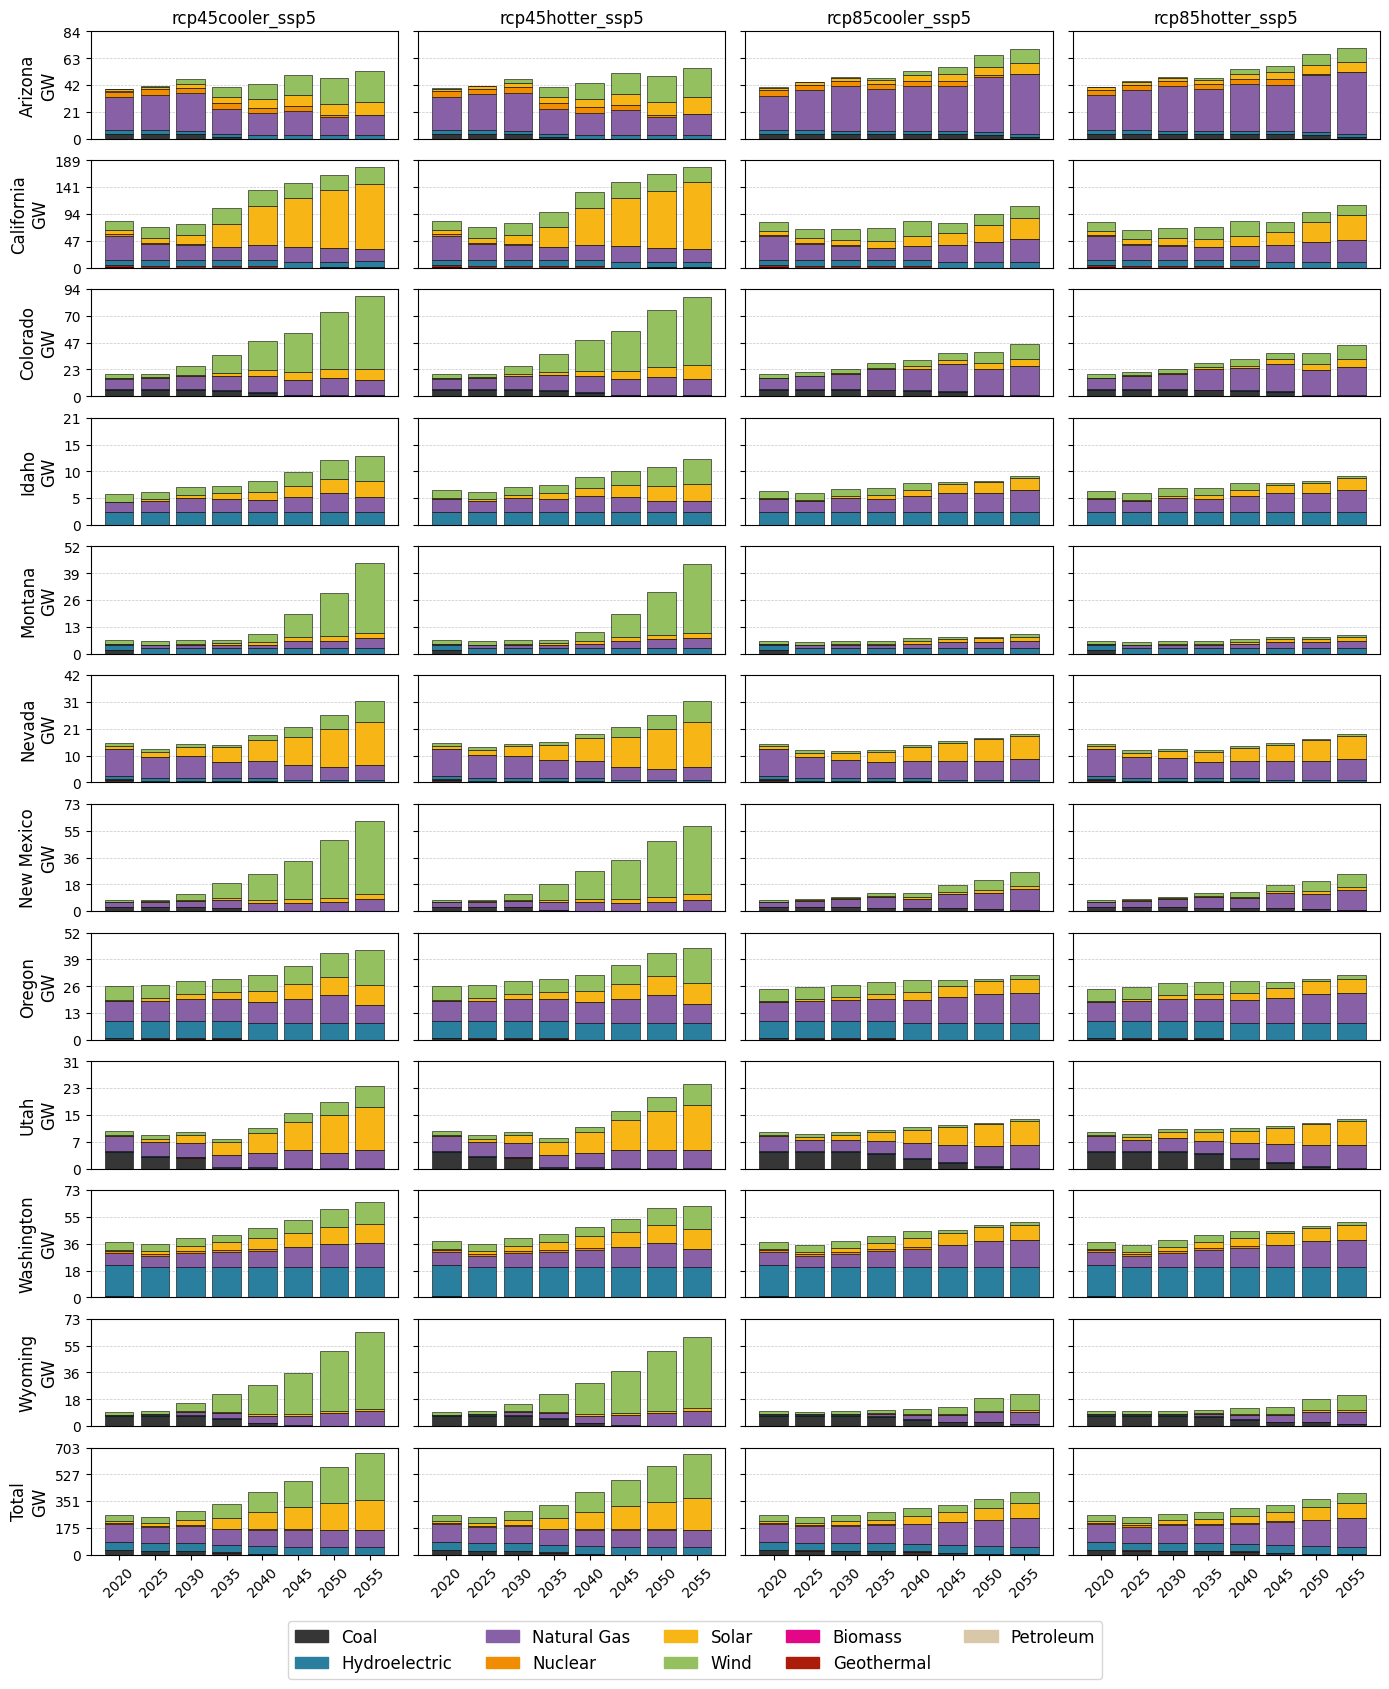

In [4]:
# read in processed data
d = pd.read_csv(os.path.join(data_dir, 'operational_power_plants_by_timestep.csv'))
d_full = d.pivot(index=['scenario', 'timestep', 'region_name'], columns='generation_type', values='unit_size_mw').fillna(0).reset_index().rename_axis(None, axis=1)
d_full = pd.melt(d_full, id_vars=['scenario', 'timestep', 'region_name'], value_vars=d_full.columns[3:],
        var_name='generation_type', value_name='unit_size_mw')
# add interconnection total
total = d_full[['scenario', 'timestep', 'generation_type', 'unit_size_mw']].groupby(['scenario', 'timestep', 'generation_type'], as_index=False).sum()
total['region_name'] = 'Total'

d = pd.concat([d, total])

subgroups = d.timestep.unique()
categories = d.generation_type.unique()

# Compute max y for each region
row_ymax_map = {}
for gr in d.region_name.unique():
    row_data = d[d['region_name'] == gr]
    if row_data.empty:
        row_ymax_map[gr] = 0
        continue
    total_per_plot = (
        row_data.groupby(['scenario', 'timestep'])['unit_size_mw'].sum()
    )
    row_max = total_per_plot.max()

    if pd.isna(row_max) or row_max == 0:
        row_ymax_map[gr] = 0
    else:
        row_ymax_map[gr] = math.ceil(row_max / 10000) * 10000
        

fontsize=12

# Create subplot grid
fig, axes = plt.subplots(nrows=12, ncols=4, figsize=(14, 18), sharey='row', constrained_layout=False)
for ax in axes.flatten():
    ax.set_xticks([])

# Plot data in each subplot
for i, gr in enumerate(d.region_name.unique()):
    for j, gc in enumerate([
        'rcp45cooler_ssp5',
        'rcp45hotter_ssp5',
        'rcp85cooler_ssp5',
        'rcp85hotter_ssp5']):
        ax = axes[i, j]
        subset = d[(d['region_name'] == gr) & (d['scenario'] == gc)]
        bottoms = np.zeros(len(subgroups))
        x = np.arange(len(subgroups))
        
        for tech in d['generation_type'].unique():
            heights = (
                subset[subset['generation_type'] == tech]
                .pivot(index='timestep', columns='generation_type', values='unit_size_mw')
                .reindex(subgroups)
                .fillna(0)[tech]
                .values
            )
            ax.bar(x, heights, bottom=bottoms, color=color_dict[tech], edgecolor='black', lw=.4) 
            bottoms += heights

        ymax = row_ymax_map[gr]
        ax.set_ylim(0, ymax*1.05)
        ax.set_axisbelow(True)
        ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x/1000)}"))

        if j == 0:
            ax.set_ylabel(f"{gr.replace('_', ' ').title()}\nGW", fontsize=fontsize)
            ax.yaxis.set_tick_params(labelleft=True, labelsize=fontsize-2)
            ax.set_yticks(np.linspace(0, ymax*1.05, 5) if ymax > 0 else [0])
        else:
            ax.yaxis.set_tick_params(labelleft=False)

        if i == 0:
            ax.set_title(gc, fontsize=fontsize)

        if i == 11:
            ax.set_xticks(x)
            ax.set_xticklabels(subgroups, fontsize=fontsize-2, rotation=45)

# Create handles
legend_order = ['Coal', 'Hydroelectric','Natural Gas', 'Nuclear','Solar', 'Wind', 'Biomass', 'Geothermal', 'Petroleum']
handles = [plt.Rectangle((0, 0), 1, 1, color=color_dict[c]) for c in legend_order]
labels = legend_order

fig.legend(handles, labels, title="", loc='center', fontsize=fontsize,
           bbox_to_anchor=(.5, -.02), borderaxespad=0., ncols=5)
fig.set_constrained_layout_pads(w_pad=0.5, h_pad=0.5, hspace=0.1, wspace=0.1)
fig.tight_layout(rect=[0, 0, 1, .9])
plt.subplots_adjust(hspace=0.2) 

plt.savefig(os.path.join(fig_dir, 'fig3.png'), dpi = 400, bbox_inches = 'tight')
plt.show()


In [15]:
gen_table_2055 = d[(d.timestep == 2055)& (d.scenario.str.contains('ssp5'))].groupby(['scenario', 'generation_type'], 
                                                                                      as_index=False).sum()
gen_table_2055 = gen_table_2055[['scenario', 'generation_type', 'unit_size_mw']]
gen_table_2055 = gen_table_2055.pivot(index='scenario', columns='generation_type', values='unit_size_mw').reset_index().fillna(0)#.reset_index()
gen_table_2055['Total'] = gen_table_2055[['Biomass', 'Coal', 'Hydroelectric', 'Natural Gas', 'Solar', 'Wind']].sum(axis=1)
gen_table_2055

generation_type,scenario,Biomass,Coal,Hydroelectric,Natural Gas,Solar,Wind,Total
0,rcp45cooler_ssp5,700.0,2600.0,99659.8,225200.0,393360.0,614694.0,1336213.8
1,rcp45hotter_ssp5,500.0,1300.0,99659.8,221000.0,418320.0,583395.0,1324174.8
2,rcp85cooler_ssp5,0.0,7122.0,99659.8,381558.0,185280.0,144366.0,817985.8
3,rcp85hotter_ssp5,0.0,7122.0,99659.8,378538.0,197760.0,132390.0,815469.8


In [17]:
for var in gen_table_2055.columns[1:]:
    if var =='Hydroelectric':
        continue
    print(var)

    A = gen_table_2055[gen_table_2055.scenario == 'rcp45cooler_ssp5'][var].iloc[0]
    B = gen_table_2055[gen_table_2055.scenario == 'rcp45hotter_ssp5'][var].iloc[0]
    C = gen_table_2055[gen_table_2055.scenario == 'rcp85cooler_ssp5'][var].iloc[0]
    D = gen_table_2055[gen_table_2055.scenario == 'rcp85hotter_ssp5'][var].iloc[0]
    
    rcp_effect = (C - A)
    gcm_effect = (B - A)
    interaction = (D - A) - (rcp_effect + gcm_effect)
    
    print(f'RCP8.5 leads to {rcp_effect} capacity compared to RCP4.5')
    print(f'hotter leads to {gcm_effect} capacity compared to cooler')
    
    relative_interaction = (np.abs(interaction)/(np.abs(rcp_effect)+np.abs(gcm_effect))) * 100
    print(f'Relative interaction is {relative_interaction.round(2)}% of main effects\n')

Biomass
RCP8.5 leads to -700.0 capacity compared to RCP4.5
hotter leads to -200.0 capacity compared to cooler
Relative interaction is 22.22% of main effects

Coal
RCP8.5 leads to 4522.0 capacity compared to RCP4.5
hotter leads to -1300.0 capacity compared to cooler
Relative interaction is 22.33% of main effects

Natural Gas
RCP8.5 leads to 156358.0 capacity compared to RCP4.5
hotter leads to -4200.0 capacity compared to cooler
Relative interaction is 0.73% of main effects

Solar
RCP8.5 leads to -208080.0 capacity compared to RCP4.5
hotter leads to 24960.0 capacity compared to cooler
Relative interaction is 5.36% of main effects

Wind
RCP8.5 leads to -470328.0 capacity compared to RCP4.5
hotter leads to -31299.0 capacity compared to cooler
Relative interaction is 3.85% of main effects

Total
RCP8.5 leads to -518228.0 capacity compared to RCP4.5
hotter leads to -12039.0 capacity compared to cooler
Relative interaction is 1.8% of main effects



## Supplemental Figure 1

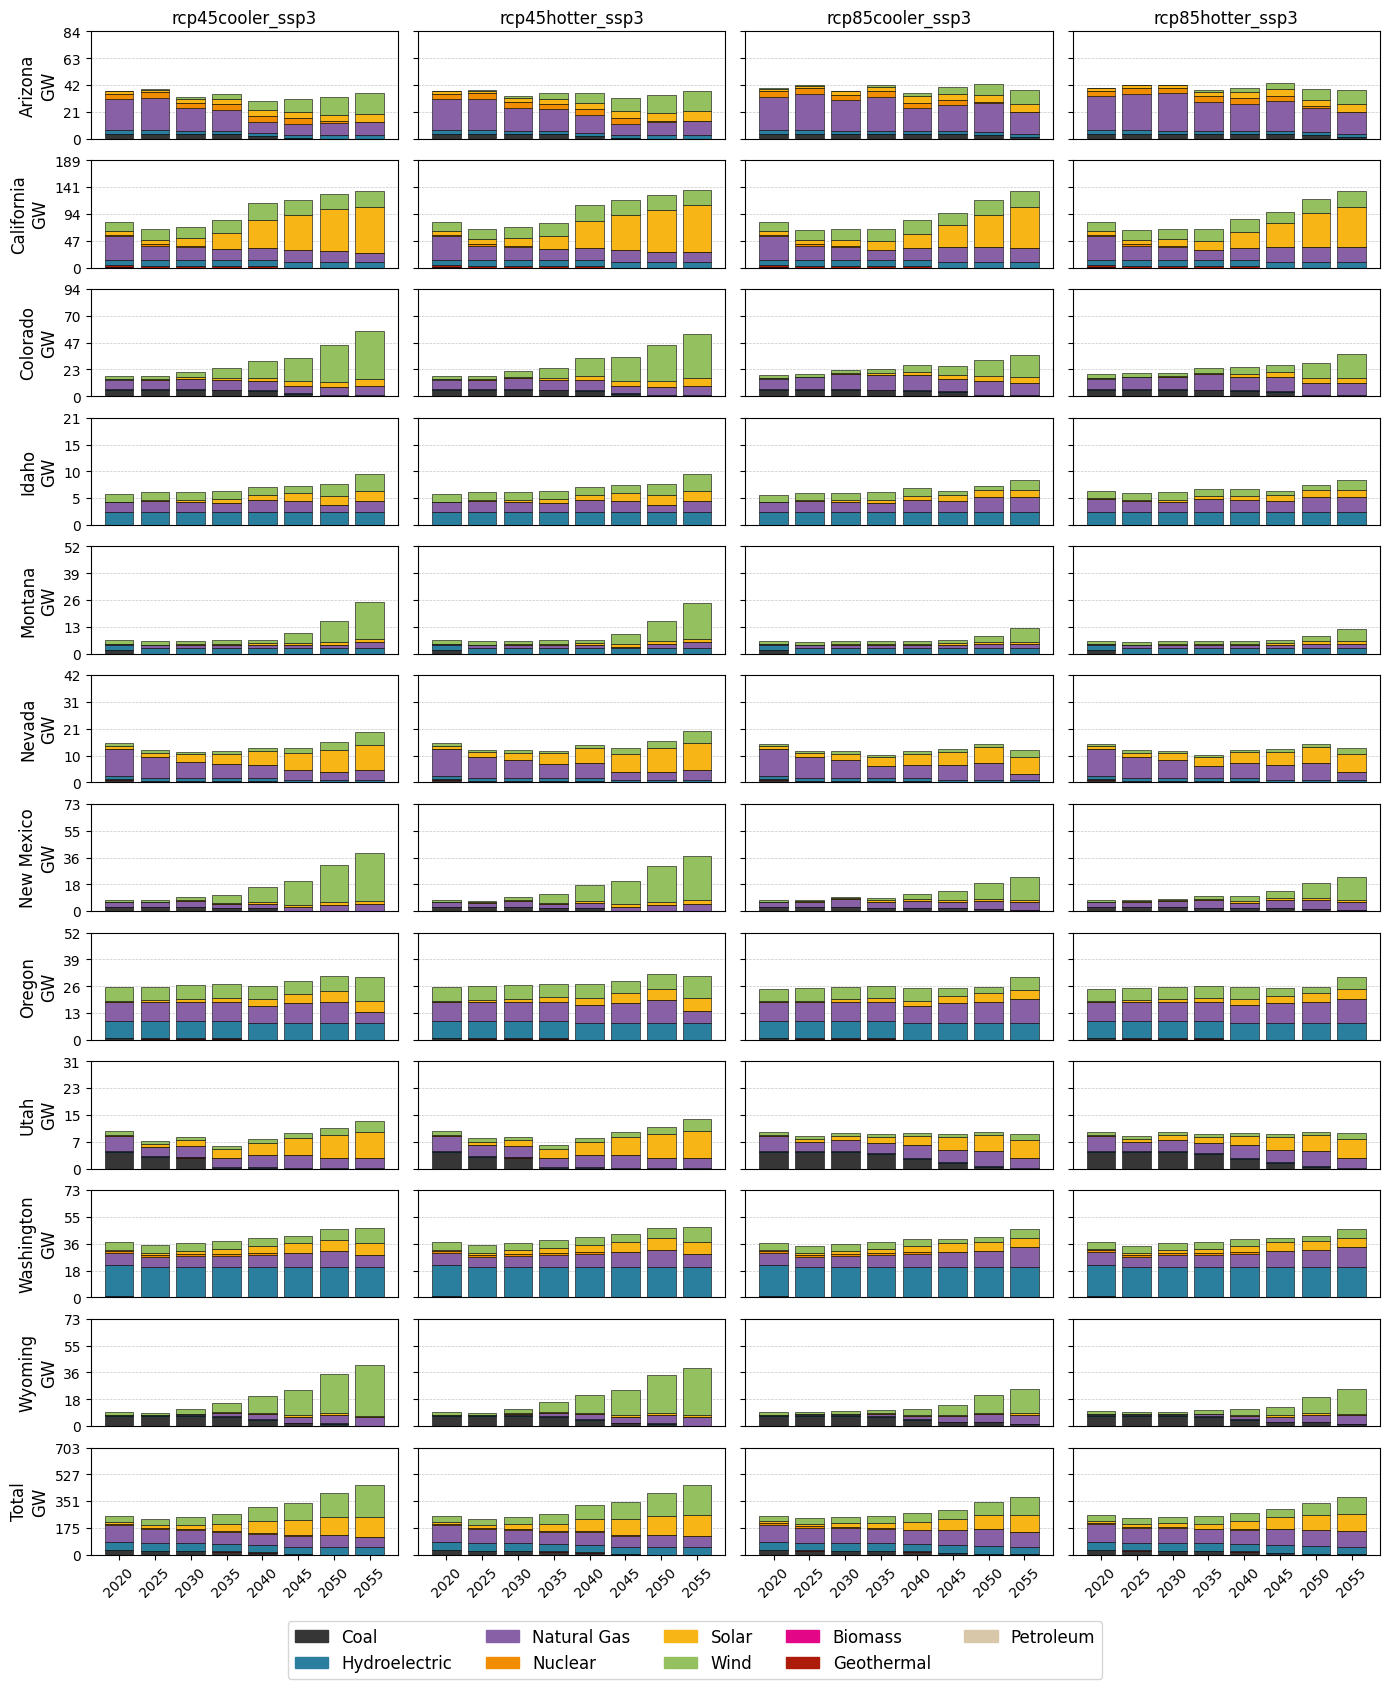

In [8]:
# read in processed data
d = pd.read_csv(os.path.join(data_dir, 'operational_power_plants_by_timestep.csv'))

# add interconnection total
total = d[['scenario', 'timestep', 'generation_type', 'unit_size_mw']].groupby(['scenario', 'timestep', 'generation_type'], as_index=False).sum()
total['region_name'] = 'Total'

d = pd.concat([d, total])

subgroups = d.timestep.unique()
categories = d.generation_type.unique()

# Compute max y for each region
row_ymax_map = {}
for gr in d.region_name.unique():
    row_data = d[d['region_name'] == gr]
    if row_data.empty:
        row_ymax_map[gr] = 0
        continue
    total_per_plot = (
        row_data.groupby(['scenario', 'timestep'])['unit_size_mw'].sum()
    )
    row_max = total_per_plot.max()

    if pd.isna(row_max) or row_max == 0:
        row_ymax_map[gr] = 0
    else:
        row_ymax_map[gr] = math.ceil(row_max / 10000) * 10000
        

fontsize=12

# Create subplot grid
fig, axes = plt.subplots(nrows=12, ncols=4, figsize=(14, 18), sharey='row', constrained_layout=False)
for ax in axes.flatten():
    ax.set_xticks([])

# Plot data in each subplot
for i, gr in enumerate(d.region_name.unique()):
    for j, gc in enumerate([
        'rcp45cooler_ssp3',
        'rcp45hotter_ssp3',
         'rcp85cooler_ssp3',
         'rcp85hotter_ssp3',]):
        ax = axes[i, j]
        subset = d[(d['region_name'] == gr) & (d['scenario'] == gc)]
        bottoms = np.zeros(len(subgroups))
        x = np.arange(len(subgroups))
        
        for tech in d['generation_type'].unique():
            heights = (
                subset[subset['generation_type'] == tech]
                .pivot(index='timestep', columns='generation_type', values='unit_size_mw')
                .reindex(subgroups)
                .fillna(0)[tech]
                .values
            )
            ax.bar(x, heights, bottom=bottoms, color=color_dict[tech], edgecolor='black', lw=.4) 
            bottoms += heights

        ymax = row_ymax_map[gr]
        ax.set_ylim(0, ymax*1.05)
        ax.set_axisbelow(True)
        ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x/1000)}"))

        if j == 0:
            ax.set_ylabel(f"{gr.replace('_', ' ').title()}\nGW", fontsize=fontsize)
            ax.yaxis.set_tick_params(labelleft=True, labelsize=fontsize-2)
            ax.set_yticks(np.linspace(0, ymax*1.05, 5) if ymax > 0 else [0])
        else:
            ax.yaxis.set_tick_params(labelleft=False)

        if i == 0:
            ax.set_title(gc, fontsize=fontsize)

        if i == 11:
            ax.set_xticks(x)
            ax.set_xticklabels(subgroups, fontsize=fontsize-2, rotation=45)

# Create handles
legend_order = ['Coal', 'Hydroelectric','Natural Gas', 'Nuclear','Solar', 'Wind', 'Biomass', 'Geothermal', 'Petroleum']
handles = [plt.Rectangle((0, 0), 1, 1, color=color_dict[c]) for c in legend_order]
labels = legend_order

fig.legend(handles, labels, title="", loc='center', fontsize=fontsize,
           bbox_to_anchor=(.5, -.02), borderaxespad=0., ncols=5)
fig.set_constrained_layout_pads(w_pad=0.5, h_pad=0.5, hspace=0.1, wspace=0.1)
fig.tight_layout(rect=[0, 0, 1, .9])
plt.subplots_adjust(hspace=0.2) 

plt.savefig(os.path.join(fig_dir, 'si_1.png'), dpi = 400, bbox_inches = 'tight')
plt.show()


# WECC ADS Comparison

### Supplemental Figure 2

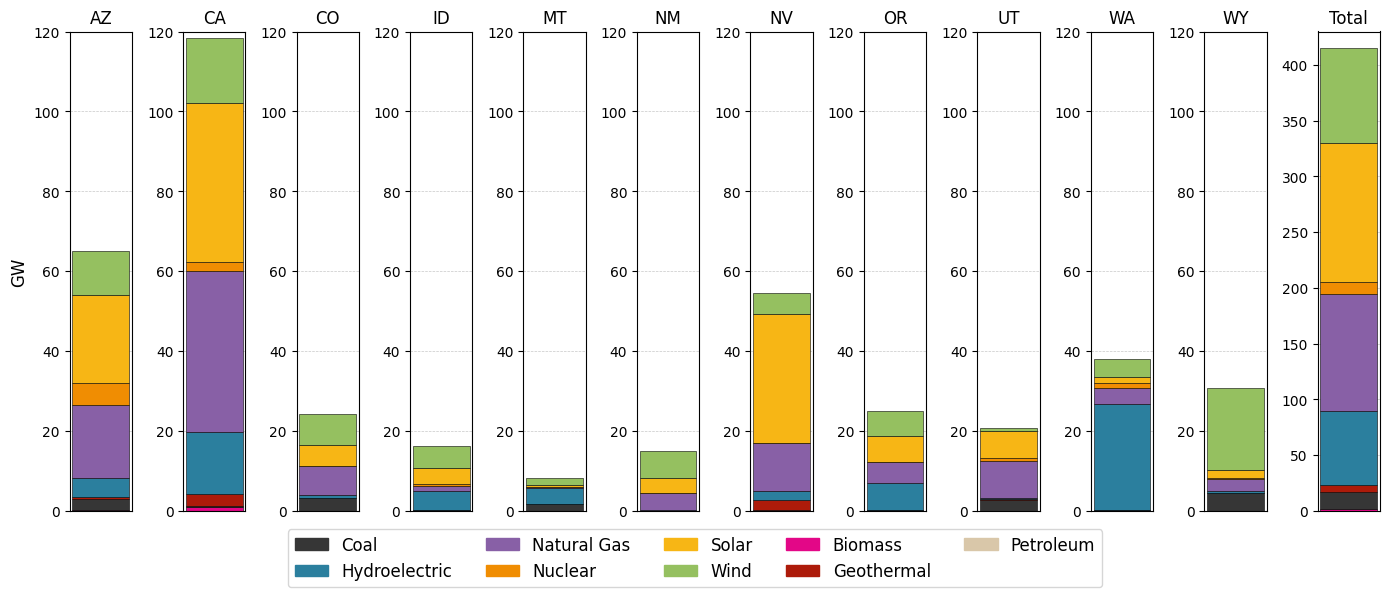

In [9]:
# read in processed data
wecc_ads =  pd.read_csv(os.path.join(data_dir, 'wecc_ads_capacity_2034.csv'))

subgroups = [2034]
categories = wecc_ads.generation_type.unique()

# Compute max y for each region
row_ymax_map = {}
for gr in wecc_ads.region_name.unique():
    row_data = wecc_ads[wecc_ads['region_name'] == gr]
    if row_data.empty:
        row_ymax_map[gr] = 0
        continue
    total_per_plot = (
        row_data.groupby(['scenario', 'timestep'])['unit_size_mw'].sum()
    )
    row_max = total_per_plot.max()

    if pd.isna(row_max) or row_max == 0:
        row_ymax_map[gr] = 0
    else:
        row_ymax_map[gr] = math.ceil(row_max / 10000) * 10000
        

fontsize=12

# Create subplot grid
fig, axes = plt.subplots(nrows=1, ncols=12, figsize=(14, 6),  constrained_layout=False)
for ax in axes.flatten():
    ax.set_xticks([])

# Plot data in each subplot
for i, gr in enumerate(wecc_ads.region_name.unique()):
    ax = axes[i]
    subset = wecc_ads[(wecc_ads['region_name'] == gr) & (wecc_ads['scenario'] == 'ADS')]
    bottoms = np.zeros(len(subgroups))
    x = np.arange(len(subgroups))
    
    for tech in wecc_ads['generation_type'].unique():
        heights = (
            subset[subset['generation_type'] == tech]
            .pivot(index='timestep', columns='generation_type', values='unit_size_mw')
            .reindex(subgroups)
            .fillna(0)[tech]
            .values
        )
        ax.bar(x, heights, bottom=bottoms, color=color_dict[tech], edgecolor='black', lw=.4) 
        bottoms += heights

    ax.set_ylim(0, 120000)
    ax.set_axisbelow(True)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x/1000)}"))

    if i==0:
        ax.set_ylabel("GW", fontsize=fontsize)
    ax.yaxis.set_tick_params(labelleft=True, labelsize=fontsize-2)

    ax.set_title(gr, fontsize=fontsize)

    if i == 11:
        ax.set_ylim(0, 430000)


# Create handles
legend_order = ['Coal', 'Hydroelectric','Natural Gas', 'Nuclear','Solar', 'Wind', 'Biomass', 'Geothermal', 'Petroleum']
handles = [plt.Rectangle((0, 0), 1, 1, color=color_dict[c]) for c in legend_order]
labels = legend_order

fig.legend(handles, labels, title="", loc='center', fontsize=fontsize,
           bbox_to_anchor=(.5, -.04), borderaxespad=0., ncols=5)
fig.set_constrained_layout_pads(w_pad=0.5, h_pad=0.5, hspace=0.1, wspace=0.1)
fig.tight_layout(rect=[0, 0, 1, .9])
plt.subplots_adjust(hspace=0.2) 

plt.savefig(os.path.join(fig_dir, 'si_2.png'), dpi = 400, bbox_inches = 'tight')
plt.show()

In [10]:
wecc_ads['unit_size_mw'] = wecc_ads['unit_size_mw'].astype(int)
wecc_ads[['generation_type', 'region_name', 'unit_size_mw']].pivot(index=['generation_type'], values='unit_size_mw',columns='region_name', ).reset_index()

region_name,generation_type,AZ,CA,CO,ID,MT,NM,NV,OR,Total,UT,WA,WY
0,Biomass,84,1030,3,69,2,0,13,191,1682,0,287,0
1,Coal,2939,18,3044,0,1626,0,219,0,14974,2730,0,4398
2,Geothermal,300,3244,0,0,0,11,2442,30,6267,238,0,0
3,Hydroelectric,4981,15401,880,4825,4086,130,2208,6703,66303,320,26306,459
4,Natural Gas,18193,40280,7163,1243,205,4208,12107,5275,105212,9234,4237,3063
5,Nuclear,5443,2300,0,462,0,0,0,0,10385,690,1145,345
6,Solar,22182,39826,5260,4178,577,3935,32312,6422,124996,6820,1608,1871
7,Wind,10873,16268,7880,5328,1769,6535,5172,6282,85729,581,4381,20655


In [11]:
print(f"The WECC ADS has a total of {wecc_ads[wecc_ads.region_name =='Total'].sum()['unit_size_mw']} MW in 2034")

The WECC ADS has a total of 415548 MW in 2034


In [12]:
gen_table = d.copy()
gen_table = gen_table[gen_table.region_name == 'Total']
gen_table = gen_table[gen_table.scenario == 'rcp45cooler_ssp5']
gen_table = gen_table[(gen_table.timestep == 2035)& (gen_table.scenario.str.contains('cooler'))].groupby(['scenario', 'region_name',
                                                                                  'generation_type'],as_index=False).sum()[['generation_type', 'unit_size_mw']]
gen_table

,generation_type,unit_size_mw
0,Coal,13544.100000
1,Geothermal,3760.800000
2,Hydroelectric,49829.900000
3,Natural Gas,99578.100000
4,Nuclear,5409.600000
5,Solar,69943.400000
6,Wind,91271.828037


In [13]:
gen_table = d.copy()
gen_table = gen_table[gen_table.scenario == 'rcp45cooler_ssp5']
gen_table = gen_table[(gen_table.timestep == 2035)& (gen_table.scenario.str.contains('cooler'))].groupby(['scenario', 'region_name',
                                                                                  'generation_type'],as_index=False).sum()[['scenario','region_name','generation_type', 'unit_size_mw']]
gen_table = gen_table.pivot(index=['scenario', 'region_name'],columns='generation_type', values='unit_size_mw').reset_index().fillna(0)#.reset_index()
gen_table

generation_type,scenario,region_name,Coal,Geothermal,Hydroelectric,Natural Gas,Nuclear,Solar,Wind
0,rcp45cooler_ssp5,Total,13544.1,3760.8,49829.9,99578.1,5409.6,69943.4,91271.828037
1,rcp45cooler_ssp5,arizona,1243.7,0.0,2718.0,19489.1,4209.6,4815.6,7848.200000
2,rcp45cooler_ssp5,california,0.0,2916.5,10043.6,23521.5,0.0,39816.9,27930.097098
3,rcp45cooler_ssp5,colorado,4602.5,0.0,661.1,12770.7,0.0,2834.0,15642.592457
4,rcp45cooler_ssp5,idaho,0.0,18.0,2541.3,2499.5,0.0,1140.0,1512.500000
5,rcp45cooler_ssp5,montana,0.0,0.0,2627.5,1454.0,0.0,1050.0,1742.180000
6,rcp45cooler_ssp5,nevada,0.0,701.8,1052.2,6207.0,0.0,5778.9,1044.300000
7,rcp45cooler_ssp5,new_mexico,1999.1,4.0,81.7,5430.4,0.0,1242.2,10732.457273
8,rcp45cooler_ssp5,oregon,642.2,36.7,8451.0,10697.9,0.0,3558.9,6492.633216
9,rcp45cooler_ssp5,utah,0.0,83.8,262.1,3635.0,0.0,3766.4,969.400000
